# BCE with Entropy Loss

This notebook analyzes and visualizes the custom Binary Cross-Entropy (BCE) loss function that is combined with a penalty based on the entropy of the predictions.

In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn.functional as F

from src.models.neural_network.bce_with_entropy_loss import BCEWithEntropyLoss, entropy

plt.style.use("seaborn-v0_8-darkgrid")

c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\kybur\Repos\HSLU\aicomp\code\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because

## Visualize BCE and Entropy
The following cell visualizes the binary cross-entropy and the entropy of the predicted probabilities.

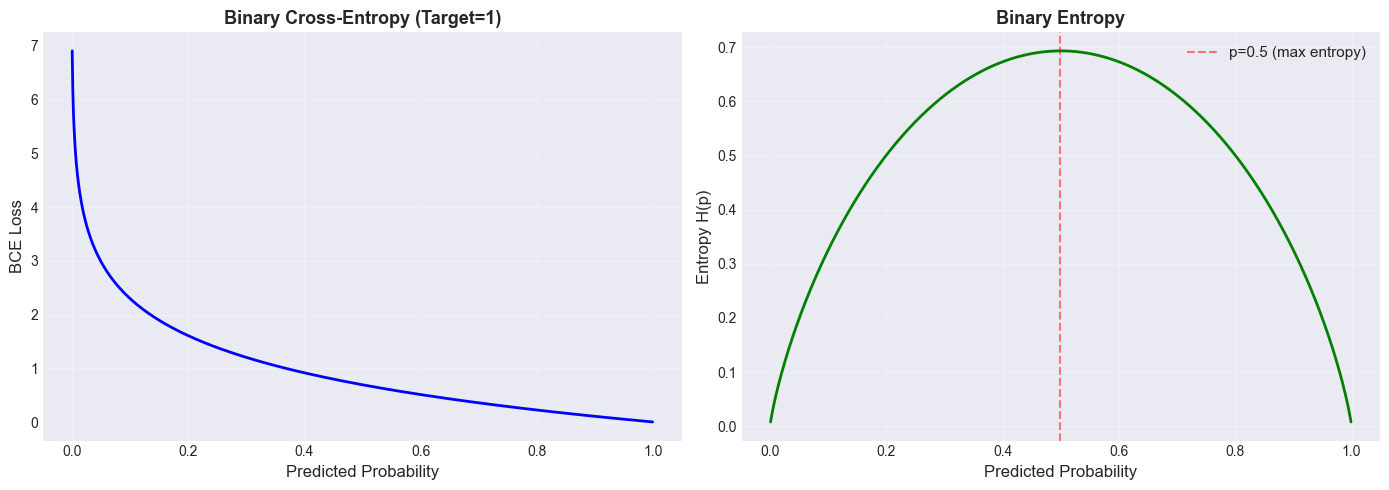

In [2]:
probs = torch.linspace(0.001, 0.999, 1000)

# Cross-Entropy & Entropy
bce_loss = F.binary_cross_entropy(probs, torch.ones_like(probs), reduction="none")
entropy_vals = entropy(probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-Entropy
axes[0].plot(probs.numpy(), bce_loss.numpy(), linewidth=2, color="blue")
axes[0].set_xlabel("Predicted Probability", fontsize=12)
axes[0].set_ylabel("BCE Loss", fontsize=12)
axes[0].set_title("Binary Cross-Entropy (Target=1)", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Entropy
max_entropy = probs[entropy_vals.argmax().item()].item()
axes[1].plot(probs.numpy(), entropy_vals.numpy(), linewidth=2, color="green")
axes[1].axvline(x=max_entropy, color="red", linestyle="--", alpha=0.5, label="p=0.5 (max entropy)")
axes[1].set_xlabel("Predicted Probability", fontsize=12)
axes[1].set_ylabel("Entropy H(p)", fontsize=12)
axes[1].set_title("Binary Entropy", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

The entropy is highest where the model is the most uncertain (p=0.5), and lowest where the model is most certain (p→0 or p→1). By adding the entropy to the BCE loss, we can encourage the model to make more confident predictions.

## Combine BCE & Entropy
The following cell shows how a new loss function could look, that combines the BCE with a penalty based on the entropy of the predictions.

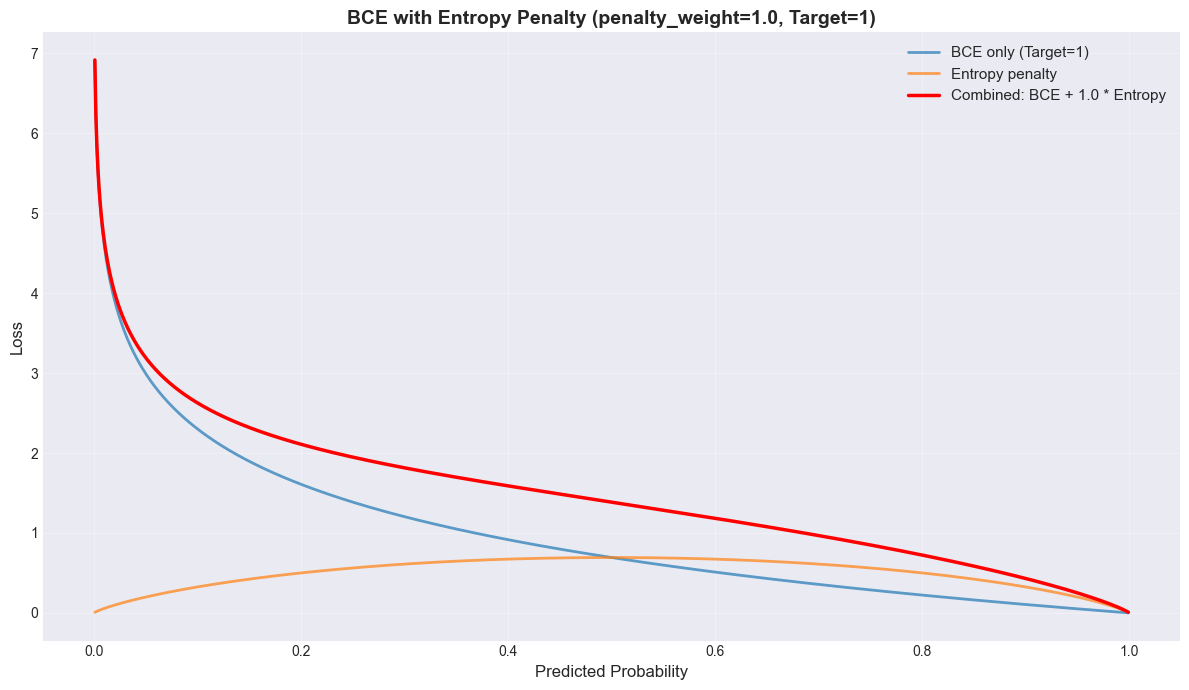

In [3]:
loss_fn = BCEWithEntropyLoss(entropy_weight=1.0, reduction="none")
combined_loss = loss_fn(probs, torch.ones_like(probs))


fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(probs.numpy(), bce_loss.numpy(), label="BCE only (Target=1)", linewidth=2, alpha=0.7)
ax.plot(probs.numpy(), entropy_vals.numpy(), label="Entropy penalty", linewidth=2, alpha=0.7)
ax.plot(probs.numpy(), combined_loss.numpy(), label="Combined: BCE + 1.0 * Entropy", linewidth=2.5, color="red")
ax.set_xlabel("Predicted Probability", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("BCE with Entropy Penalty (penalty_weight=1.0, Target=1)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()

The figure above shows how adding the entropy to the BCE loss increases the loss uncertain predictions get, while still keeping the loss at the target (1) the lowest.

## Weighing the Entropy Penalty
The following figures show a few examples of different weights for the entropy penalty added to the BCE loss.

In [4]:
def show_loss_with_weight(penalty_weights):
    assert len(penalty_weights) % 2 == 0, "Provide exactly four penalty weights for visualization."

    fig, axes = plt.subplots(len(penalty_weights) // 2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, pw in enumerate(penalty_weights):
        loss_fn_temp = BCEWithEntropyLoss(entropy_weight=pw, reduction="none")

        # Calculate losses for target=0 and target=1
        losses_target_0 = torch.zeros_like(probs)
        losses_target_1 = torch.zeros_like(probs)

        losses_target_0 = loss_fn_temp(probs, torch.zeros_like(probs))
        losses_target_1 = loss_fn_temp(probs, torch.ones_like(probs))

        ax = axes[idx]
        ax.plot(probs.numpy(), losses_target_0.numpy(), label="Target=0", linewidth=2, alpha=0.7)
        ax.plot(probs.numpy(), losses_target_1.numpy(), label="Target=1", linewidth=2, alpha=0.7)
        ax.set_xlabel("Predicted Probability", fontsize=11)
        ax.set_ylabel("Loss", fontsize=11)
        ax.set_title(f"Penalty Weight = {pw}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    fig.suptitle("Effect of Different Penalty Weights", fontsize=14, fontweight="bold", y=1.00)
    fig.tight_layout()

    return fig

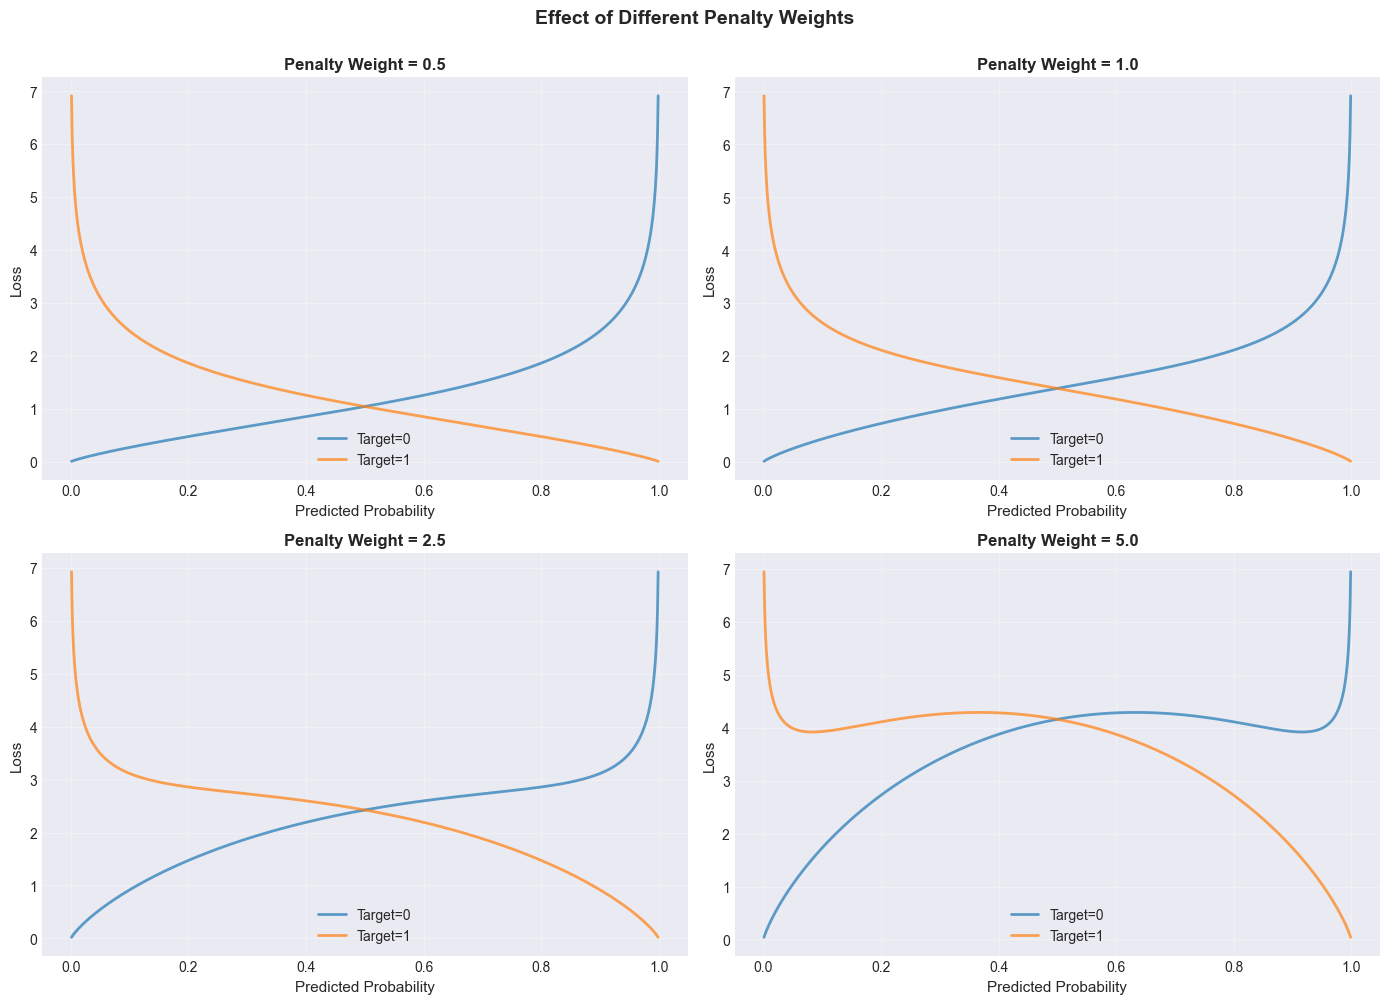

In [5]:
show_loss_with_weight([0.5, 1.0, 2.5, 5.0]);

The effect of the weight is pretty straight forward: the higher the weight, the stronger is the penalty for uncertain predictions. However a weight too high can lead to a lower loss for predictions that are further away from the target, see e.g. the weight=5.0.

### Maximum Penalty Weight
The following cell tries to find the maximum penalty weight that keeps all losses for predictions closer to the target lower than the losses for predictions further away from the target.

In [6]:
def find_max_penalty_weight(num_points=1000, tolerance=1e-6):
    """
    Find the maximum penalty weight that maintains monotonicity of the loss.

    For target=1.0: Loss should strictly decrease as prediction increases from 0 to 1
    For target=0.0: Loss should strictly decrease as prediction decreases from 1 to 0

    Returns:
        max_weight: Maximum penalty weight that keeps loss monotonic
        violation_point: The probability where violation first occurs (if any)
    """
    probs = torch.linspace(0.001, 0.999, num_points)

    # Binary search for maximum weight
    low, high = 0.0, 10.0
    max_valid_weight = 0.0
    violation_prob = None

    while high - low > tolerance:
        mid = (low + high) / 2

        # Create loss function with this weight
        loss_fn = BCEWithEntropyLoss(entropy_weight=mid, reduction="none")

        losses = loss_fn(probs, torch.ones_like(probs))
        diffs = losses[1:] - losses[:-1]
        is_monotonic = torch.all(diffs <= tolerance).item()

        if is_monotonic:
            max_valid_weight = mid
            low = mid
        else:
            violation_idx = torch.where(diffs > tolerance)[0]

            if len(violation_idx) > 0:
                violation_prob = probs[violation_idx[0]].item()
            high = mid

    return max_valid_weight, violation_prob

  Maximum penalty weight: 3.591957
  Violation starts at p ≈ 0.2168


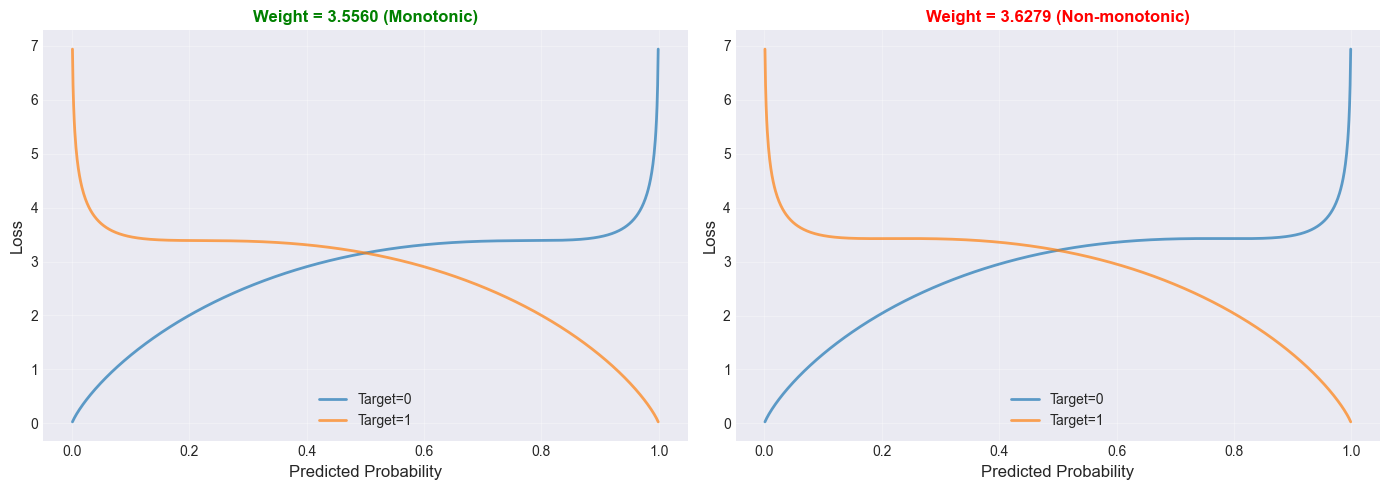

In [7]:
max_weight_target, violation = find_max_penalty_weight()

print(f"  Maximum penalty weight: {max_weight_target:.6f}")
if violation:
    print(f"  Violation starts at p ≈ {violation:.4f}")
else:
    print(f"  No violation found (monotonic throughout)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
probs_vis = torch.linspace(0.001, 0.999, 1000)

# A weight just below the max
safe_weight = max_weight_target * 0.99
loss_fn_safe = BCEWithEntropyLoss(entropy_weight=safe_weight, reduction="none")
losses_safe_0 = loss_fn_safe(probs_vis, torch.zeros_like(probs_vis))
losses_safe_1 = loss_fn_safe(probs_vis, torch.ones_like(probs_vis))

# A weight just above the max
unsafe_weight = max_weight_target * 1.01
loss_fn_unsafe = BCEWithEntropyLoss(entropy_weight=unsafe_weight, reduction="none")
losses_unsafe_0 = loss_fn_unsafe(probs_vis, torch.zeros_like(probs_vis))
losses_unsafe_1 = loss_fn_unsafe(probs_vis, torch.ones_like(probs_vis))

# Safe weight plot
axes[0].plot(probs_vis.numpy(), losses_safe_0.numpy(), label="Target=0", linewidth=2, alpha=0.7)
axes[0].plot(probs_vis.numpy(), losses_safe_1.numpy(), label="Target=1", linewidth=2, alpha=0.7)
axes[0].set_xlabel("Predicted Probability", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title(f"Weight = {safe_weight:.4f} (Monotonic)", fontsize=12, fontweight="bold", color="green")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Unsafe weight plot
axes[1].plot(probs_vis.numpy(), losses_unsafe_0.numpy(), label="Target=0", linewidth=2, alpha=0.7)
axes[1].plot(probs_vis.numpy(), losses_unsafe_1.numpy(), label="Target=1", linewidth=2, alpha=0.7)
axes[1].set_xlabel("Predicted Probability", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=12)
axes[1].set_title(f"Weight = {unsafe_weight:.4f} (Non-monotonic)", fontsize=12, fontweight="bold", color="red")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Given the binary search above, the maximum weight that should be used for the custom loss function is approximately **3.55**. the next cell will show the weights of 2.5, 3, 3.25 & 3.5, which could be candidates for default weights to use in upcoming training:

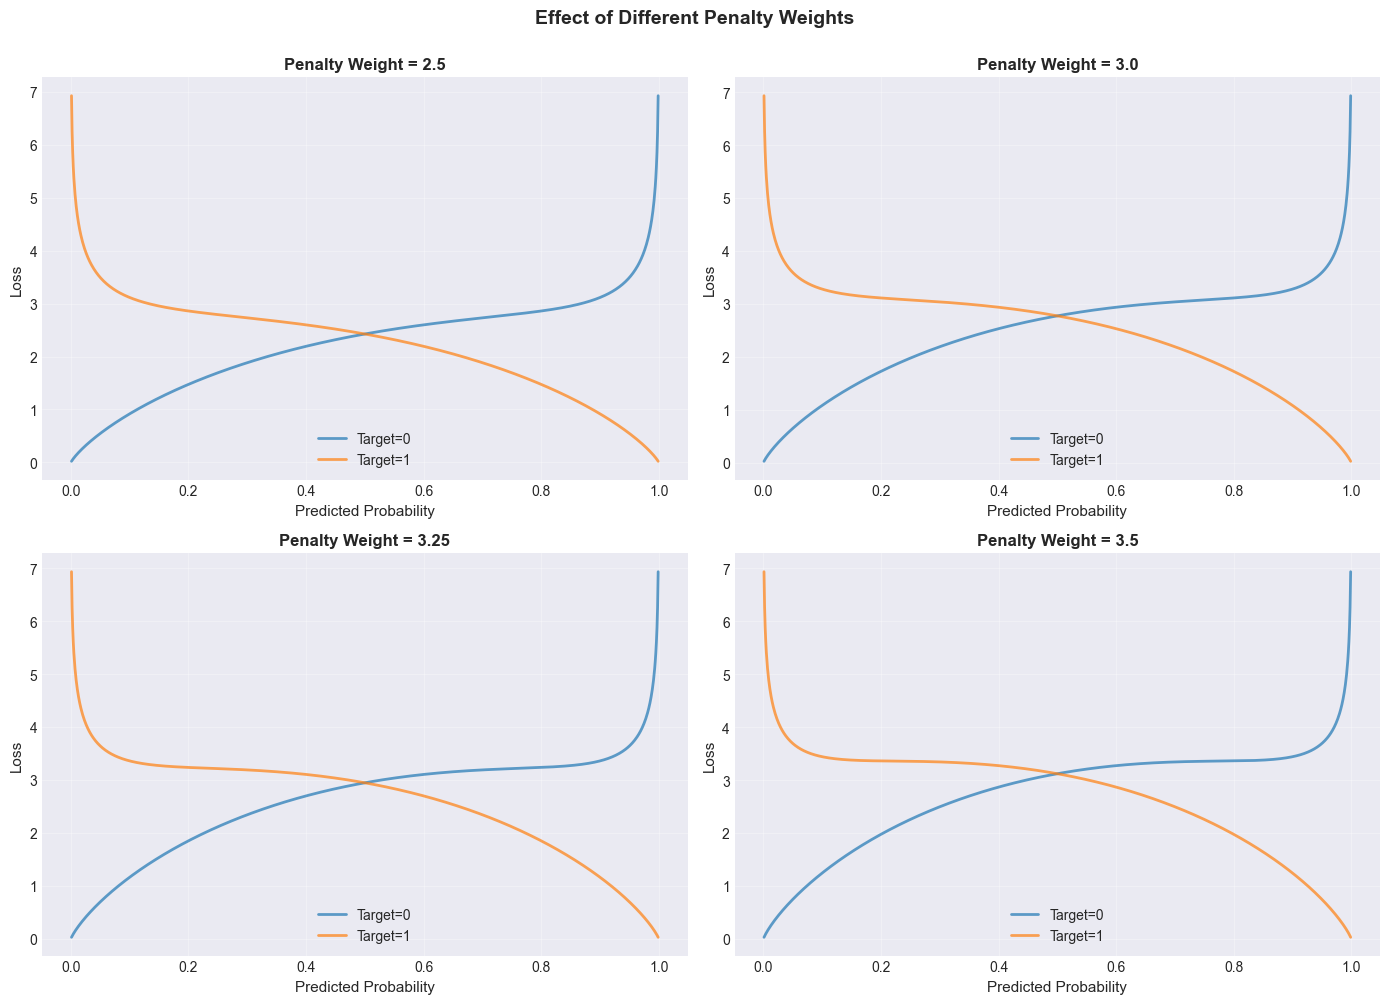

In [8]:
show_loss_with_weight([2.5, 3.0, 3.25, 3.5]);

Based on these graphs a weight of **3.5** seems to be a good choice when the goal is to make a model produce (over) confident predictions.

In [9]:
def show_loss_with_weight(penalty_weight):
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    loss_fn_temp = BCEWithEntropyLoss(entropy_weight=penalty_weight, reduction="none")

    # Calculate losses for target=0 and target=1
    losses_target_0 = torch.zeros_like(probs)
    losses_target_1 = torch.zeros_like(probs)

    losses_target_0 = loss_fn_temp(probs, torch.zeros_like(probs))
    losses_target_1 = loss_fn_temp(probs, torch.ones_like(probs))

    ax.plot(probs.numpy(), losses_target_0.numpy(), label="Target=0", linewidth=2, alpha=0.7)
    ax.plot(probs.numpy(), losses_target_1.numpy(), label="Target=1", linewidth=2, alpha=0.7)
    ax.set_xlabel("Predicted Probability", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title(f"Penalty Weight = {penalty_weight}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    fig.suptitle("BCE with Entropy Penalty", fontsize=14, fontweight="bold", y=1.00)
    fig.tight_layout()

    return fig

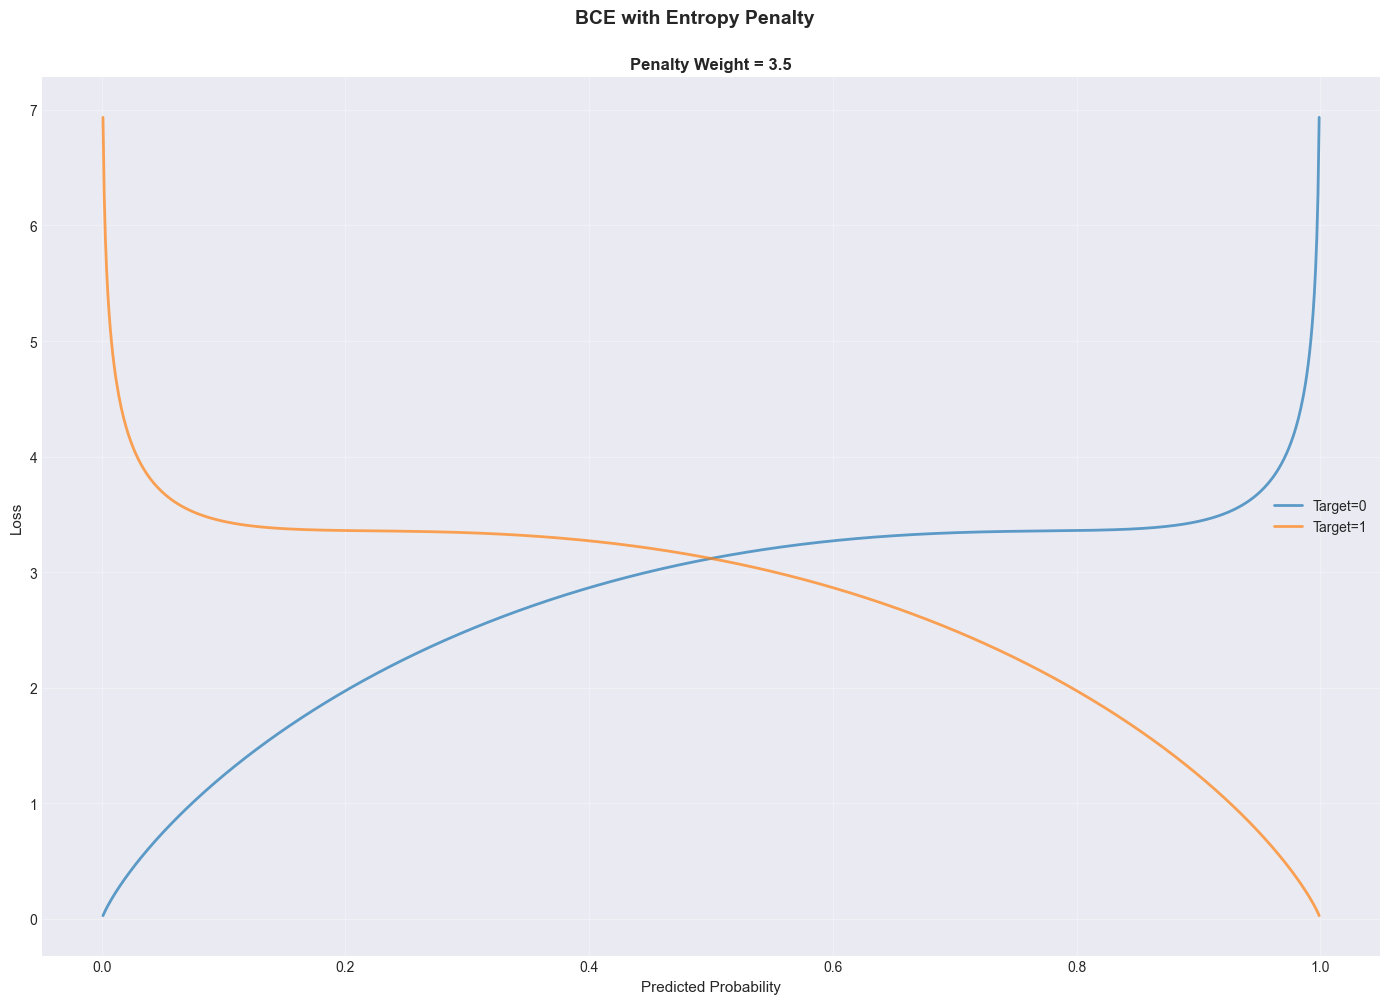

In [10]:
show_loss_with_weight(3.5);